In [51]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [52]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
Y = np.array([-1, 1, 1, -1])

In [53]:
def encode(x):
    qc = QuantumCircuit(2)
    qc.ry(np.pi * x[0], 0)
    qc.ry(np.pi * x[1], 1)
    return qc

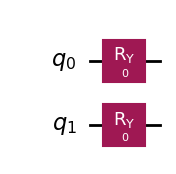

In [54]:
encode(X[0]).draw(output="mpl")

In [55]:
N_LAYERS = 1  # 2 params per layer + 2 final = 2*N_LAYERS+2 total params

def entangling_layer(qc, theta, theta_offset):
    qc.ry(theta[theta_offset + 0], 0)
    qc.ry(theta[theta_offset + 1], 1)
    qc.cx(0, 1)

def classifier_head(qc, theta):
    qc.ry(theta[-2], 0)
    qc.ry(theta[-1], 1)


def ansatz(theta):
    qc = QuantumCircuit(2)
    for l in range(N_LAYERS):
        entangling_layer(qc, theta, theta_offset=l * 2)
    classifier_head(qc, theta)
    return qc

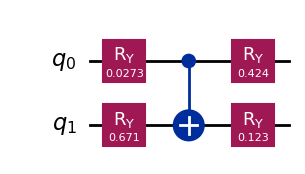

In [56]:
theta_demo = np.random.rand(2 * N_LAYERS + 2)
ansatz(theta_demo).draw(output="mpl")

In [57]:
def build_circuit(x, theta):
    qc = QuantumCircuit(2)
    qc.compose(encode(x), inplace=True)
    qc.compose(ansatz(theta), inplace=True)
    return qc

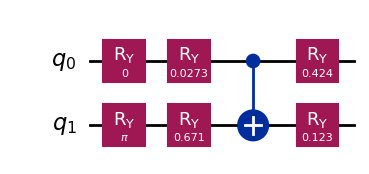

In [58]:
build_circuit(X[1], theta_demo).draw(output="mpl")

In [59]:
def forward(x, theta):
    qc = build_circuit(x, theta)
    state = Statevector.from_instruction(qc)
    return float(np.real(state.expectation_value([[1, 0], [0, -1]], [0])))

In [60]:
def loss(theta, X, Y):
    preds = np.array([forward(x, theta) for x in X])
    return float(np.mean((preds - Y) ** 2))

In [61]:
result = minimize(loss, np.random.rand(2 * N_LAYERS + 2), args=(X, Y), method='COBYLA')
theta_opt = result.x


print("Optimized theta:", theta_opt)
print("Final loss:", result.fun)

Optimized theta: [1.57073131 1.57077536 1.57077866 0.8174002 ]
Final loss: 7.51784635625345e-18


In [62]:
pred_labels = np.array([1 if forward(x, theta_opt) >= 0 else -1 for x in X])
accuracy = np.mean(pred_labels == Y)

print("Accuracy:", accuracy)
for x, y_true, y_pred in zip(X, Y, pred_labels):
    marker = "Y" if y_true == y_pred else "N"
    print(f"  {marker}  x={x}  true={y_true:+d}  pred={y_pred:+d}")

Accuracy: 1.0
  Y  x=[0. 0.]  true=-1  pred=-1
  Y  x=[0. 1.]  true=+1  pred=+1
  Y  x=[1. 0.]  true=+1  pred=+1
  Y  x=[1. 1.]  true=-1  pred=-1


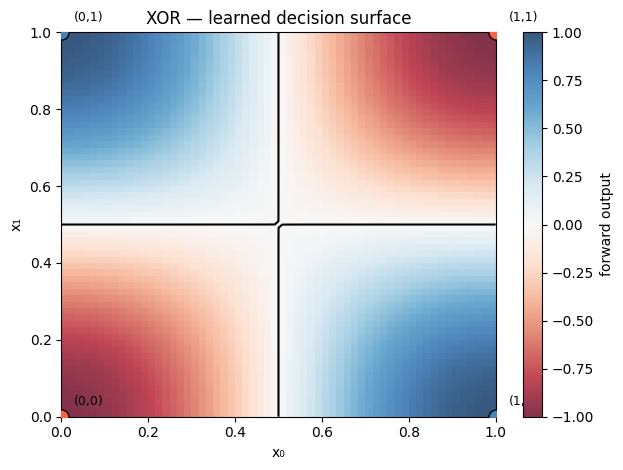

In [63]:
resolution = 60
grid = np.linspace(0, 1, resolution)
g0, g1 = np.meshgrid(grid, grid)

Z_values = []
for a, b in zip(g0.ravel(), g1.ravel()):
    x_temp = np.array([a, b])
    Z_values.append(forward(x_temp, theta_opt))

Z = np.array(Z_values).reshape(resolution, resolution)


fig, ax = plt.subplots()
im = ax.imshow(Z, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.8)
ax.contour(g0, g1, Z, levels=[0], colors="k", linewidths=1.5)
plt.colorbar(im, ax=ax, label="forward output")

colors = {1: "steelblue", -1: "tomato"}
for x, y_true in zip(X, Y):
    ax.scatter(x[0], x[1], c=colors[y_true], edgecolors="k", s=120, zorder=5)
    ax.text(x[0] + 0.03, x[1] + 0.03, f"({int(x[0])},{int(x[1])})", fontsize=9)

ax.set_xlabel("x₀")
ax.set_ylabel("x₁")
ax.set_title("XOR — learned decision surface")
plt.tight_layout()
plt.show()

In [64]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(4, 4),
    activation='tanh',
    solver='adam',
    alpha=1e-4,
    max_iter=5000,
    random_state=42,
 )
mlp.fit(X, Y)

pred_classical = mlp.predict(X)
accuracy_classical = np.mean(pred_classical == Y)

print("Classical MLP Accuracy:", accuracy_classical)
for x, y_true, y_pred in zip(X, Y, pred_classical):
    marker = "✓" if y_true == y_pred else "✗"
    print(f"  {marker}  x={x}  true={y_true:+d}  pred={y_pred:+d}")
print()
print("VQC Accuracy:", np.mean(pred_labels == Y))


Classical MLP Accuracy: 1.0
  ✓  x=[0. 0.]  true=-1  pred=-1
  ✓  x=[0. 1.]  true=+1  pred=+1
  ✓  x=[1. 0.]  true=+1  pred=+1
  ✓  x=[1. 1.]  true=-1  pred=-1

VQC Accuracy: 1.0


In [65]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X, Y)

pred_svm = svm.predict(X)
accuracy_svm = np.mean(pred_svm == Y)

print("SVM (RBF) Accuracy:", accuracy_svm)
for x, y_true, y_pred in zip(X, Y, pred_svm):
    marker = "✓" if y_true == y_pred else "✗"
    print(f"  {marker}  x={x}  true={y_true:+d}  pred={y_pred:+d}")


SVM (RBF) Accuracy: 1.0
  ✓  x=[0. 0.]  true=-1  pred=-1
  ✓  x=[0. 1.]  true=+1  pred=+1
  ✓  x=[1. 0.]  true=+1  pred=+1
  ✓  x=[1. 1.]  true=-1  pred=-1


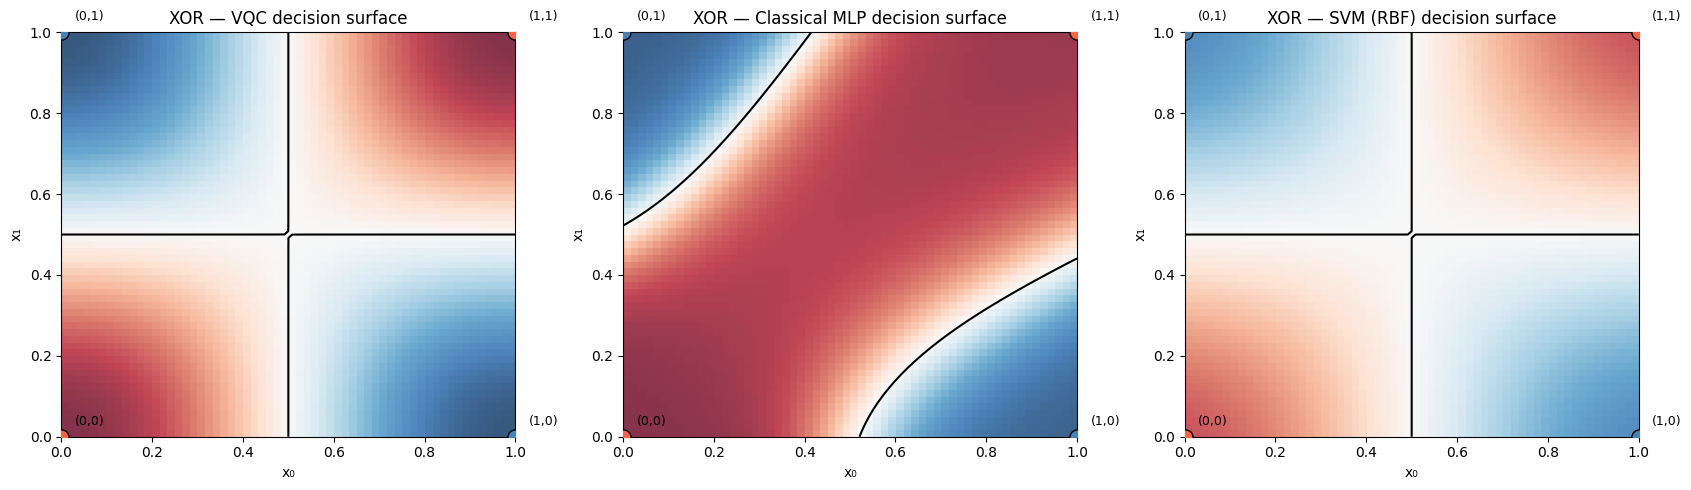

In [66]:
resolution = 60
grid = np.linspace(0, 1, resolution)
g0, g1 = np.meshgrid(grid, grid)
grid_2d = np.column_stack([g0.ravel(), g1.ravel()])

Z_vqc = np.array([forward(p, theta_opt) for p in grid_2d]).reshape(resolution, resolution)
# Use continuous scores so all three plots render with gradients like the VQC
Z_mlp = (mlp.predict_proba(grid_2d)[:, 1] * 2 - 1).reshape(resolution, resolution)
Z_svm = svm.decision_function(grid_2d).reshape(resolution, resolution)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_map = {1: "steelblue", -1: "tomato"}

for ax, Z, title in zip(axes, [Z_vqc, Z_mlp, Z_svm], ["VQC", "Classical MLP", "SVM (RBF)"]):
    ax.imshow(Z, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.8)
    ax.contour(g0, g1, Z, levels=[0], colors="k", linewidths=1.5)
    for x, y_true in zip(X, Y):
        ax.scatter(x[0], x[1], c=colors_map[y_true], edgecolors="k", s=120, zorder=5)
        ax.text(x[0] + 0.03, x[1] + 0.03, f"({int(x[0])},{int(x[1])})", fontsize=9)
    ax.set_xlabel("x₀")
    ax.set_ylabel("x₁")
    ax.set_title(f"XOR — {title} decision surface")

plt.tight_layout()
plt.show()
